# Predicting the Sale Price of Bulldozers using ML

In this notebook, we're going to go through an example machine learning
project with the goal of predicting the sale price of bulldozers.

## 1. Problem Definition

> How well can we predict the future sale price of a bulldozer, given
its characteristics and previous examples of how much similar bulldozer
have been sold for?

## 2. Data

The data is downloaded from the Kaggle Bluebook for Bulldozers competition.

There are 3 main datasets:

* Train.csv is the training set, which contains data through the end of 2011.
* Valid.csv is the validation set, which contains data from January 1, 2012-
April 30, 2012. We make predictions on this set throughout the majority of the
competition. Our score on this set is used to create the public leaderboard.
* Test.csv is the test set, which won't be released until the last week of the
competition. It contains data from May 1, 2012 - November 2012. We calculate
score on the test set, determine our final rank for the competition.


## 3. Evaluation

The evaluation metric fro this competition is the RMSLE(root mean squared log
error) between the actual and predicted auction prices.

**Note**: The goal for most regression evaluation metrics is to minimize the error.
For example, our goal for this project will be to build a machine learning model
which minimises RMSLE.

## 4. Features

Kaggle provides a data dictionary detailing all of the features of the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Bulldozer Price Prediction/bluebook-for-bulldozers/TrainAndValid.csv', low_memory=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [5]:
df.isna().sum(), df.isna().sum().size

(SalesID                          0
 SalePrice                        0
 MachineID                        0
 ModelID                          0
 datasource                       0
 auctioneerID                 20136
 YearMade                         0
 MachineHoursCurrentMeter    265194
 UsageBand                   339028
 saledate                         0
 fiModelDesc                      0
 fiBaseModel                      0
 fiSecondaryDesc             140727
 fiModelSeries               354031
 fiModelDescriptor           337882
 ProductSize                 216605
 fiProductClassDesc               0
 state                            0
 ProductGroup                     0
 ProductGroupDesc                 0
 Drive_System                305611
 Enclosure                      334
 Forks                       214983
 Pad_Type                    331602
 Ride_Control                259970
 Stick                       331602
 Transmission                224691
 Turbocharged               

In [6]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

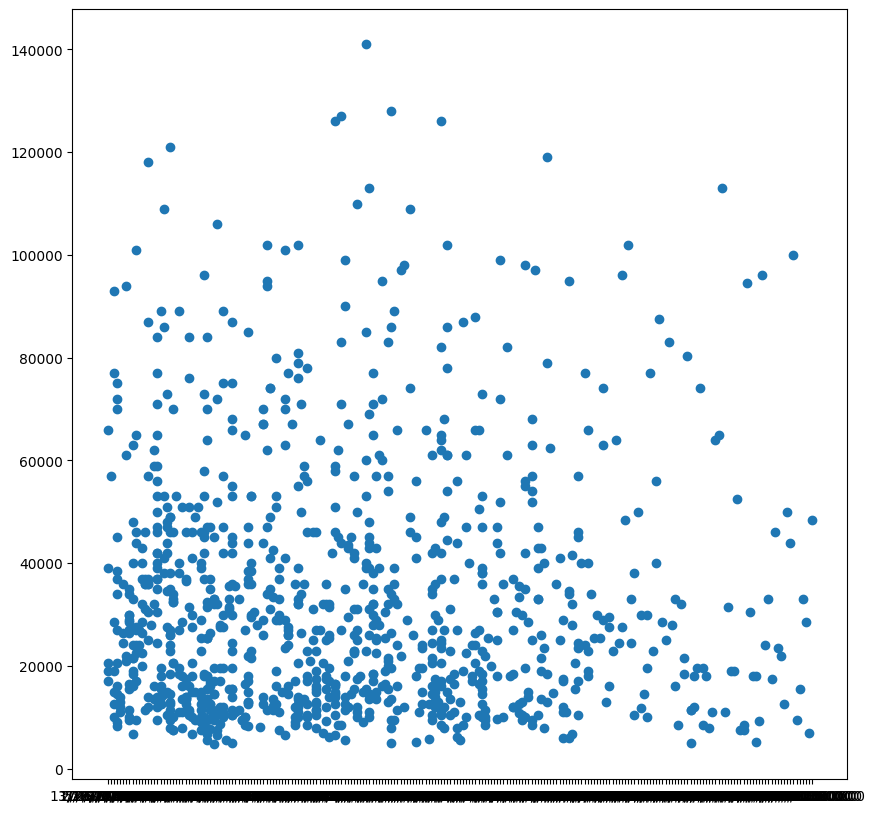

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(df.saledate[:1000], df.SalePrice[:1000])

In [8]:
df["saledate"][:1000]

,saledate
0,11/16/2006 0:00
1,3/26/2004 0:00
2,2/26/2004 0:00
3,5/19/2011 0:00
4,7/23/2009 0:00
...,...
995,7/16/2009 0:00
996,6/14/2007 0:00
997,9/22/2005 0:00
998,7/28/2005 0:00


<Axes: ylabel='Frequency'>

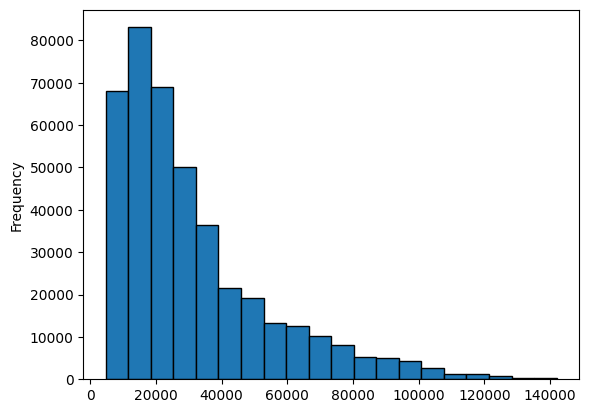

In [9]:
df["SalePrice"].plot.hist(bins=20, edgecolor="black")

In [10]:
df = pd.read_csv('/content/drive/MyDrive/Bulldozer Price Prediction/bluebook-for-bulldozers/TrainAndValid.csv',
                 low_memory=False,
                 parse_dates=["saledate"])

In [11]:
df.saledate[:1000]

,saledate
0,2006-11-16
1,2004-03-26
2,2004-02-26
3,2011-05-19
4,2009-07-23
...,...
995,2009-07-16
996,2007-06-14
997,2005-09-22
998,2005-07-28


In [12]:
df.saledate.dtype

dtype('<M8[ns]')

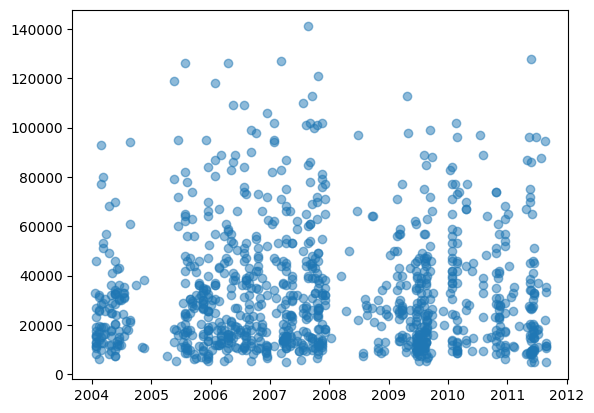

In [13]:
fig, ax = plt.subplots()
ax.scatter(df.saledate[:1000], df.SalePrice[:1000], alpha=0.5)
# ax.scatter(df.saledate[:1000], df.ModelID[:1000], marker="*", alpha=0.5)

In [14]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


### Sort DataFrame by saledate

When working with time series data, it's a good idea to sort it by date.

In [15]:
# Sort DataFrame in date order

df.sort_values(by=["saledate"], inplace=True, ascending=True)

In [16]:
df.saledate.head(20)

,saledate
205615,1989-01-17
274835,1989-01-31
141296,1989-01-31
212552,1989-01-31
62755,1989-01-31
54653,1989-01-31
81383,1989-01-31
204924,1989-01-31
135376,1989-01-31
113390,1989-01-31


In [17]:
df.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [18]:
# Make a copy
df_temp = df.copy()

In [19]:
df_temp.saledate[:1], df_temp.saledate[:1].dt.year, df_temp.saledate[:1].dt.month


(205615   1989-01-17
 Name: saledate, dtype: datetime64[ns],
 205615    1989
 Name: saledate, dtype: int32,
 205615    1
 Name: saledate, dtype: int32)

In [20]:
df_temp.saledate[:1], df_temp.saledate[:1].dt.day

(205615   1989-01-17
 Name: saledate, dtype: datetime64[ns],
 205615    17
 Name: saledate, dtype: int32)

### Add datetime parameters for saledate column

In [21]:
df_temp["saleYear"] = df_temp.saledate.dt.year
df_temp["saleMonth"] = df_temp.saledate.dt.month
df_temp["saleDay"] = df_temp.saledate.dt.day
df_temp["saleDayOfWeek"] = df_temp.saledate.dt.dayofweek
df_temp["saleDayOfYear"] = df_temp.saledate.dt.dayofyear

In [22]:
df_temp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [23]:
# Now we've enriched our DataFrame with date time features, we can remove "saledate"

df_temp.drop("saledate", axis=1, inplace=True)

In [24]:
# Check the values of different columns

df_temp.state.value_counts()

,count
state,
Florida,67320
Texas,53110
California,29761
Washington,16222
Georgia,14633
Maryland,13322
Mississippi,13240
Ohio,12369
Illinois,11540


## 5. Modeling

We'we done enough EDA(we could always do more) but let's start to do some model - driven EDA.

In [25]:
# Let's build a machine learning model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs=-1,
                              random_state=42)


In [26]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   fiModelDesc               412698 non-null  object 
 10  fiBaseModel               412698 non-null  object 
 11  fiSecondaryDesc           271971 non-null  object 
 12  fiModelSeries             58667 non-null   object 
 13  fiModelDescriptor         74816 non-null   o

In [27]:
df_temp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,20136
YearMade,0
MachineHoursCurrentMeter,265194
UsageBand,339028
fiModelDesc,0


### Convert string into categories

One way we can turn all of our data into numbers is by converting them into pandas categories.

In [28]:
df_temp.UsageBand.dtype

dtype('O')

In [29]:
pd.api.types.is_object_dtype(df_temp["UsageBand"])

True

In [30]:
 # Find the columns which contain strings
for label, content in df_temp.items():
  if pd.api.types.is_object_dtype(content):
    print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [31]:
# If yor're wondering what df.items() does, here's an example
random_dict = {"key1": "hello",
               "key2": "world!"}

for key, value in random_dict.items():
  print(f"this is a key: {key}",
        f"this is a value: {value}")

this is a key: key1 this is a value: hello
this is a key: key2 this is a value: world!


In [32]:
for label, content in df_temp.items():
  if pd.api.types.is_object_dtype(content):
    df_temp[label] = content.astype("category").cat.as_ordered()

In [33]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [34]:
df_temp.state.cat.categories


Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [35]:
df_temp.state.value_counts()

,count
state,
Florida,67320
Texas,53110
California,29761
Washington,16222
Georgia,14633
Maryland,13322
Mississippi,13240
Ohio,12369
Illinois,11540


In [36]:
df_temp.state.cat.codes

,0
205615,43
274835,8
141296,8
212552,8
62755,8
...,...
410879,4
412476,4
411927,4
407124,4


*Thanks* to pandas Categories we now have a way to access all of our data
in form of numbers.

But we still have a bunch of missing data...

In [37]:
# Check missing data
df_temp.isnull().sum()/len(df_temp)

,0
SalesID,0.000000
SalePrice,0.000000
MachineID,0.000000
ModelID,0.000000
datasource,0.000000
auctioneerID,0.048791
YearMade,0.000000
MachineHoursCurrentMeter,0.642586
UsageBand,0.821492
fiModelDesc,0.000000


### Save perprocessed data

In [38]:
# Export currnet temp dataframe
df_temp.to_csv("/content/drive/MyDrive/Bulldozer Price Prediction/bluebook-for-bulldozers/train_tmp.csv",
               index=False)

In [39]:
# Import Preprocessed Data
df_temp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [40]:
# Import preprocessed data
dr_temp = pd.read_csv("/content/drive/MyDrive/Bulldozer Price Prediction/bluebook-for-bulldozers/train_tmp.csv",
                      low_memory = False)
df_temp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [41]:
df_temp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,20136
YearMade,0
MachineHoursCurrentMeter,265194
UsageBand,339028
fiModelDesc,0


### Fill missing values

#### Fill numberical missing values first

In [42]:
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfWeek
saleDayOfYear


In [43]:
# Check for which numeric columns have null values
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(label)

auctioneerID
MachineHoursCurrentMeter


In [44]:
# Fill numeric rows with medium
for label,content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      # Add a binary column which tells us if the data was missing or not
      df_temp[label+"_is_missing"] = pd.isnull(content)
      # Fill missing numeric values with median
      df_temp[label] = content.fillna(content.median(), inplace=True)

In [45]:
df_temp.auctioneerID.isna().sum()

412698

In [46]:
df_temp.auctioneerID.median();

/usr/local/lib/python3.11/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [47]:
hundreds = np.full((1000,), 100)
hundreds_billion = np.append(hundreds, 1000000000)
np.mean(hundreds), np.mean(hundreds_billion), np.median(hundreds), np.median(hundreds_billion)

(100.0, 999100.8991008991, 100.0, 100.0)

In [48]:
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(label)

In [49]:
df_temp.auctioneerID_is_missing.value_counts()

,count
auctioneerID_is_missing,
False,392562
True,20136


In [50]:
df_temp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,412698
YearMade,0
MachineHoursCurrentMeter,412698
UsageBand,339028
fiModelDesc,0


In [51]:
df_temp.auctioneerID_is_missing

,auctioneerID_is_missing
205615,False
274835,False
141296,False
212552,False
62755,False
...,...
410879,False
412476,False
411927,False
407124,False


In [52]:
df_temp.auctioneerID_is_missing.value_counts()

,count
auctioneerID_is_missing,
False,392562
True,20136


In [53]:
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(f"Column Name : {label}, Missing Value : True")
    else:
      print(f"Column Name : {label}, Missing Value : False")

Column Name : SalesID, Missing Value : False
Column Name : SalePrice, Missing Value : False
Column Name : MachineID, Missing Value : False
Column Name : ModelID, Missing Value : False
Column Name : datasource, Missing Value : False
Column Name : YearMade, Missing Value : False
Column Name : saleYear, Missing Value : False
Column Name : saleMonth, Missing Value : False
Column Name : saleDay, Missing Value : False
Column Name : saleDayOfWeek, Missing Value : False
Column Name : saleDayOfYear, Missing Value : False
Column Name : auctioneerID_is_missing, Missing Value : False
Column Name : MachineHoursCurrentMeter_is_missing, Missing Value : False


### Filling and turning categorical variables into numbers

In [54]:
len = 0
for label, content in df_temp.items():
  if not pd.api.types.is_numeric_dtype(content):
    print(f"Column Name : {label} | Column dtype : {df_temp[label].dtype.name}")
    len += 1
print(len)

Column Name : auctioneerID | Column dtype : object
Column Name : MachineHoursCurrentMeter | Column dtype : object
Column Name : UsageBand | Column dtype : category
Column Name : fiModelDesc | Column dtype : category
Column Name : fiBaseModel | Column dtype : category
Column Name : fiSecondaryDesc | Column dtype : category
Column Name : fiModelSeries | Column dtype : category
Column Name : fiModelDescriptor | Column dtype : category
Column Name : ProductSize | Column dtype : category
Column Name : fiProductClassDesc | Column dtype : category
Column Name : state | Column dtype : category
Column Name : ProductGroup | Column dtype : category
Column Name : ProductGroupDesc | Column dtype : category
Column Name : Drive_System | Column dtype : category
Column Name : Enclosure | Column dtype : category
Column Name : Forks | Column dtype : category
Column Name : Pad_Type | Column dtype : category
Column Name : Ride_Control | Column dtype : category
Column Name : Stick | Column dtype : category


In [55]:
# 1. Create a dictionary to store column to category values (e.g we turn our category types into numbers but we keep a record so we can go back)
column_to_category_dict = {}

# 2. Turn categorical variables into numbers
for label, content in df_temp.items():

  # 3. Check Column's which aren't numberic
  if not pd.api.types.is_numeric_dtype(content):

    # 4. Add binary column to indicate wheater sample had missing value
    df_temp[label+"is_missing"] = pd.isnull(content).astype(int)

    # 5. Ensure content is categorical and get its category codes
    content_categories = pd.Categorical(content)
    content_category_codes = content_categories.codes + 1

    # 6. Add column key to dictionary with code: category mapping per column
    column_to_category_dict[label] = dict(zip(content_category_codes, content_categories))

    # 7. Set the column to the numerical values(the category code value)
    df_temp[label] = content_category_codes

In [56]:
df_temp.head(10).T

,205615,274835,141296,212552,62755,54653,81383,204924,135376,113390
SalesID,1646770,1821514,1505138,1671174,1329056,1301884,1379228,1645390,1493279,1449549
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0,23500.0,31000.0,11750.0,63000.0,13000.0
MachineID,1126363,1194089,1473654,1327630,1336053,1182999,1082797,1527216,1363756,1289412
ModelID,8434,10150,4139,8591,4089,4123,7620,8202,2759,3356
datasource,132,132,132,132,132,132,132,132,132,132
...,...,...,...,...,...,...,...,...,...,...
Backhoe_Mountingis_missing,0,1,0,1,0,0,1,1,0,1
Blade_Typeis_missing,0,1,0,1,0,0,1,1,0,1
Travel_Controlsis_missing,0,1,0,1,0,0,1,1,0,1
Differential_Typeis_missing,1,0,1,0,1,1,0,0,1,1


In [57]:
pd.Categorical(df_temp["state"]).codes + 1

array([44,  9,  9, ...,  5,  5,  5], dtype=int8)

In [58]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Columns: 105 entries, SalesID to Steering_Controlsis_missing
dtypes: bool(2), float64(1), int16(4), int32(5), int64(51), int8(42)
memory usage: 195.2 MB


In [59]:
# Check the first 10 state column values
for key, value in sorted(column_to_category_dict["state"].items())[:10]:
  print(f"{key} -> {value}")

1 -> Alabama
2 -> Alaska
3 -> Arizona
4 -> Arkansas
5 -> California
6 -> Colorado
7 -> Connecticut
8 -> Delaware
9 -> Florida
10 -> Georgia


In [60]:
df_temp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
...,...
Backhoe_Mountingis_missing,0
Blade_Typeis_missing,0
Travel_Controlsis_missing,0
Differential_Typeis_missing,0


Now that all of data is numeric as well as our dataframe has no missing values,
we should be able to build a machine learning model.

In [65]:
df_temp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Widthis_missing,Stick_Lengthis_missing,Thumbis_missing,Pattern_Changeris_missing,Grouser_Typeis_missing,Backhoe_Mountingis_missing,Blade_Typeis_missing,Travel_Controlsis_missing,Differential_Typeis_missing,Steering_Controlsis_missing
205615,1646770,9500.0,1126363,8434,132,0,1974,0,0,4593,...,1,1,1,1,1,0,0,0,1,1
274835,1821514,14000.0,1194089,10150,132,0,1980,0,0,1820,...,1,1,1,1,1,1,1,1,0,0
141296,1505138,50000.0,1473654,4139,132,0,1978,0,0,2348,...,1,1,1,1,1,0,0,0,1,1
212552,1671174,16000.0,1327630,8591,132,0,1980,0,0,1819,...,1,1,1,1,1,1,1,1,0,0
62755,1329056,22000.0,1336053,4089,132,0,1984,0,0,2119,...,1,1,1,1,1,0,0,0,1,1


In [62]:
%%time
# Instantiate model
model = RandomForestRegressor(n_jobs=-1,
                              random_state=42)
# Fit the model
model.fit(df_temp.drop("SalePrice", axis=1), df_temp["SalePrice"])

CPU times: user 22min 35s, sys: 7.15 s, total: 22min 42s
Wall time: 13min 50s


RandomForestRegressor(n_jobs=-1, random_state=42)